A deliberately simple 20/60-day moving-average crossover backtest, run across several assets and benchmarked against buy-and-hold — kept naive on purpose to show where a trend rule fails.

In [1]:
# trading strategy 

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### get_data — download adjusted close, compute daily returns and the 20/60-day moving averages

In [2]:
def get_data(ticker, start, end):
  
    data=yf.download(ticker, start=start, end =end, auto_adjust=False)['Adj Close']
   # yfinance returns multi index ddata frames
    data = data.dropna()
    data= data.rename(columns={ticker: 'price'})
    data.columns = ['price']
    data['returns'] = (data['price']-data['price'].shift(1))/ data['price'].shift(1)
    data['ma_fast']= data['price'].rolling(20).mean()
    data['ma_slow']=data['price'].rolling(60).mean()

    return data
    



### gen_signal — +1 when fast MA > slow MA, else -1, shifted one day to avoid lookahead

In [3]:
def gen_signal(data):
    data=data.copy()
    data['signal']= np.where(data['ma_fast']>data['ma_slow'], 1, -1)
    data['signal']= data['signal'].shift(1) # prevents look ahead bias

    data['strategy_returns'] = data['signal']*data['returns'] # buying day later if fast>slow & vice versa
    return data


### plot_returns — cumulative strategy return vs buy-and-hold

In [4]:
def plot_returns(data):
    data=data.copy()
    data=data.dropna()
    data['cum_returns'] = (1+ data['strategy_returns']).cumprod()
    data['buynhold']=(1+data['returns']).cumprod()

    plt.figure(figsize=(12,8))
    plt.plot(data['cum_returns'], label='Cumulative Return', color= 'tab:red', lw=2)
    plt.plot(data['buynhold'], label= 'buy and hold', lw =2, color='tab:blue')

    plt.ylabel('Returns ($dollars)')
    plt.xlabel('Date')
    plt.xticks(rotation=45)
    plt.legend(loc='upper left')

    plt.title('Moving Average Strategy')

    plt.show()

    return data


### Demo: Brent crude (BZ=F), 2020–2024

[*********************100%***********************]  1 of 1 completed


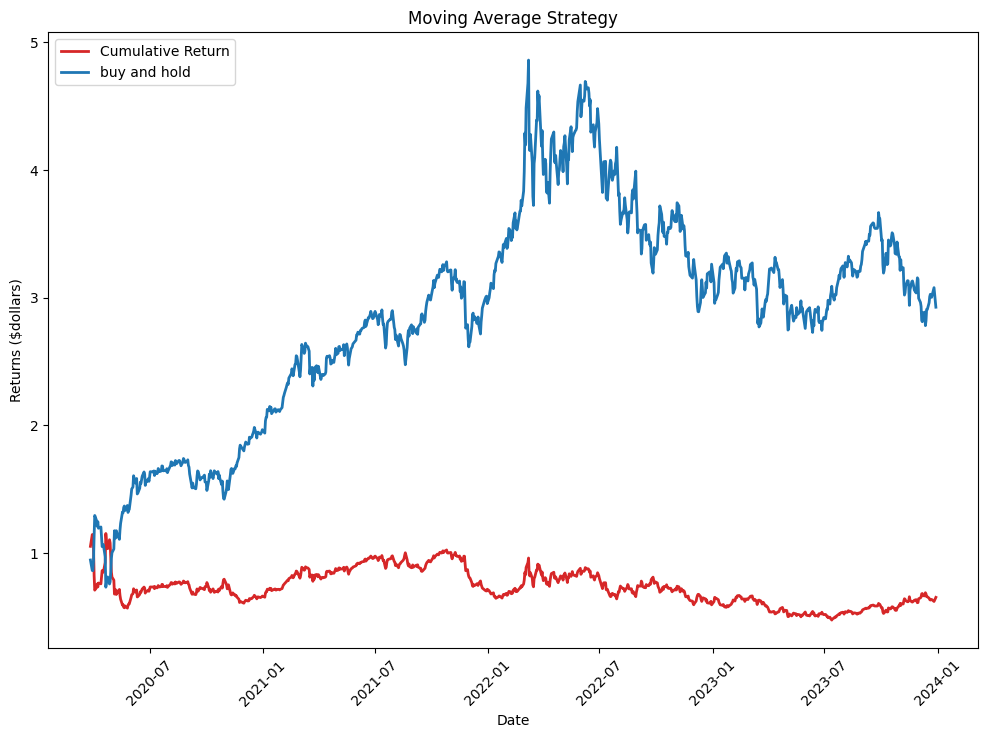

,price,returns,ma_fast,ma_slow,signal,strategy_returns,cum_returns,buynhold
Date,,,,,,,,
2020-03-27,24.930000,-0.053531,34.8270,51.400333,-1.0,0.053531,1.053531,0.946469
2020-03-30,22.760000,-0.087044,33.3700,50.675500,-1.0,0.087044,1.145234,0.864085
2020-03-31,22.740000,-0.000879,31.9140,49.911167,-1.0,0.000879,1.146240,0.863326
2020-04-01,24.740000,0.087951,30.5945,49.175000,-1.0,-0.087951,1.045428,0.939256
2020-04-02,29.940001,0.210186,29.5920,48.536167,-1.0,-0.210186,0.825693,1.136674
...,...,...,...,...,...,...,...,...
2023-12-22,79.070000,-0.004031,77.8960,83.107167,-1.0,0.004031,0.638290,3.001898
2023-12-26,81.070000,0.025294,77.9505,82.946500,-1.0,-0.025294,0.622145,3.077828
2023-12-27,79.650002,-0.017516,77.8490,82.758667,-1.0,0.017516,0.633042,3.023918


In [5]:
df_crude= get_data('BZ=F', '2020-01-01', '2024-01-01')
df_crude=gen_signal(df_crude)
plot_returns(df_crude)

### Cross-asset summary

Final cumulative return per asset over the window each was originally trialled on. Recorded results from my runs are in the README.

In [ ]:
# cross-asset summary: final strategy vs buy-and-hold for every asset trialled
# windows differ between assets so this is NOT a controlled comparison

assets = {
    'BZ=F': ('2020-01-01', '2024-01-01'),
    'GC=F': ('2020-01-01', '2025-01-01'),
    'GLEN.L': ('2001-01-01', '2025-01-01'),
    'AAPL': ('2001-01-01', '2020-01-01'),
    'SHEL': ('2001-01-01', '2020-01-01'),
    'bp': ('2001-01-01', '2020-01-01'),
    'TSLA': ('2001-01-01', '2025-01-01'),
}

rows = []
for ticker, (start, end) in assets.items():
    data = get_data(ticker, start, end)
    data = gen_signal(data)
    data = data.dropna()
    strategy = (1 + data['strategy_returns']).cumprod().iloc[-1]
    buynhold = (1 + data['returns']).cumprod().iloc[-1]
    rows.append([ticker, start + ' to ' + end, round(strategy, 3), round(buynhold, 3)])

summary = pd.DataFrame(rows, columns=['ticker', 'window requested', 'strategy final', 'buy and hold final'])
summary